In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random
from typing import Tuple, List, Dict, Any

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.datasets import load_digits
from sklearn.decomposition import PCA

from skimage.feature import hog

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
import pytorch_lightning as pl
from torchvision import datasets, transforms
from torchmetrics import Accuracy

plt.rcParams['figure.figsize'] = (10, 6)

W0326 17:19:32.353000 25248 site-packages\torch\utils\flop_counter.py:29] triton not found; flop counting will not work for triton kernels


# Лабораторная работа №3 (доработанная)



## Теоретическая часть

### Решающие деревья

Решающее дерево — это непараметрический метод обучения с учителем, который строит модель в виде набора простых правил вида "если‐то". Дерево разбивает пространство признаков на области, а в листовых узлах хранит предсказания. Среди преимуществ деревьев — простота интерпретации и способность работать с числовыми и категориальными данными; для их использования не требуется масштабирование признаков, а прогнозирование имеет логарифмическую сложность по числу обучающих примеров. Недостатком одиночных деревьев является высокая дисперсия и склонность к переобучению.

### Метод опорных векторов (SVM)

Метод опорных векторов — семейство алгоритмов обучения с учителем, используемых для классификации, регрессии и задач обнаружения выбросов. Он ищет разделяющую гиперплоскость с максимальным зазором между классами в пространстве признаков. К достоинствам SVM относят эффективность в задачах с большим числом признаков, способность работать, когда число признаков превышает число примеров, и использование лишь части обучающих точек (опорных векторов), что делает модель компактной. Метод поддерживает различные ядра, что позволяет строить нелинейные разделяющие поверхности. Среди недостатков — необходимость подбора ядра и параметров регуляризации и дорогая оценка вероятностей.

### Случайный лес

Случайный лес — ансамблевый алгоритм, который объединяет множество решающих деревьев, построенных на случайных подвыборках данных и случайных поднаборах признаков. Деревья обучаются на bootstrap-выборках; для каждого узла рассматривается случайное подмножество признаков. Такая случайность снижает дисперсию моделей: отдельные деревья переобучаются, но усреднение их предсказаний приводит к более устойчивой модели. В реализациях scikit‑learn усредняются вероятностные предсказания деревьев, что часто увеличивает точность.

### Преобразование признаков и сокращение размерности

**Histogram of Oriented Gradients (HOG).** Визуальный дескриптор HOG анализирует распределение ориентаций градиентов в локальных областях изображения. Для каждого пикселя вычисляются величина и направление градиента, затем изображение разбивается на ячейки, и в каждой строится гистограмма направлений. Дескриптор акцентирует структуру или форму объекта, поскольку учитывает не только наличие границы, но и её направление. Итоговый признак для изображения представляет собой вектор, содержащий гистограммы для всех ячеек.

**Local Binary Pattern (LBP).** LBP — простой дескриптор текстуры. Для каждой точки берутся пиксели в окружности; значения сравниваются с центральным пикселем, образуя двоичный код, который интерпретируется как число. Сопоставляя гистограммы LBP по всему изображению, можно описывать типы текстур. На схеме LBP показано, что сравниваются восемь соседей; последовательности из всех чёрных или белых точек соответствуют ровным областям, а чередование указывает на углы или более сложные структуры.

**Principal Component Analysis (PCA).** PCA — метод линейного снижения размерности, который разлагает исходные данные на набор ортогональных компонентов, объясняющих наибольшую дисперсию. Алгоритм центрирует данные и находит главные компоненты с помощью сингулярного разложения; полученный трансформер позволяет проектировать новые данные в пространство меньшей размерности. Параметр `whiten=True` масштабирует компоненты до единичной дисперсии, что бывает полезно для алгоритмов, чувствительных к масштабу признаков.



### Разминочные задания

#### Задание A. Классификация простых прямоугольников

1. Сгенерируйте синтетический набор изображений. Каждое изображение – это трёхканальный массив фиксированного размера (например, 20×20 пикселей). Внутри изображения находится прямоугольник одного из цветов: красный (значение 1 только в красном канале), зелёный или синий. Ширина и высота прямоугольника выбираются случайным образом в пределах заданного диапазона.
2. Сформируйте выборку изображений и соответствующие метки классов: 0 — красный прямоугольник, 1 — зелёный, 2 — синий. Преобразуйте изображения в табличный вид, развернув их в одномерные векторы признаков.
3. Разделите данные на обучающую и тестовую выборки (например, 70 % / 30 %). Обучите три классификатора: решающее дерево (`DecisionTreeClassifier`), линейный SVM (`SVC(kernel='linear')`) и случайный лес (`RandomForestClassifier`).
4. Оцените точность каждого алгоритма на тестовой выборке и сравните результаты.

#### Задание B. Классификация рукописных цифр с классическими признаками

1. Загрузите набор данных `load_digits` из `sklearn.datasets` (это упрощённый аналог MNIST: изображения 8×8 пикселей). Разделите выборку на обучающую и тестовую.
2. Для каждого изображения извлеките признаки с помощью дескриптора HOG. Для этого можно использовать функцию `skimage.feature.hog` и указать параметры `orientations=9`, `pixels_per_cell=(4,4)`, `cells_per_block=(1,1)`. Получите матрицу признаков.
3. При необходимости уменьшите размерность признаков с помощью `PCA` до разумного числа компонент (например, 20).
4. Обучите и сравните три классификатора: решающее дерево, SVM с радиальным ядром (`SVC(kernel='rbf')`) и случайный лес. Выведите точность каждого алгоритма на тестовой выборке.
5. Проанализируйте, какие методы показали лучшие результаты на этом наборе данных и почему.


In [2]:
# ===== Задание A =====
def generate_rectangles(num_samples: int = 1000) -> Tuple[np.ndarray, np.ndarray]:
    images = []
    labels =[]
    
    for _ in range(num_samples):
        # Создаем черный холст [H, W, C]
        img = np.zeros((20, 20, 3), dtype=np.float32)
        
        w = random.randint(5, 15)
        h = random.randint(5, 15)
        x = random.randint(0, 20 - w)
        y = random.randint(0, 20 - h)
        
        color_idx = random.randint(0, 2)
        img[y:y+h, x:x+w, color_idx] = 1.0 
        
        images.append(img)
        labels.append(color_idx)
        
    return np.array(images), np.array(labels)

X_img, y = generate_rectangles(30000)
X = X_img.reshape(X_img.shape[0], -1) 

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

models = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Linear SVM": SVC(kernel='linear', random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42)
}

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)
    print(f"{name}: Accuracy = {acc:.4f}")


Decision Tree: Accuracy = 0.9994
Linear SVM: Accuracy = 1.0000
Random Forest: Accuracy = 1.0000


In [3]:
digits = load_digits()
images = digits.images # [1797, 8, 8]
labels = digits.target # [1797]

hog_features =[]
for img in images:
    fd = hog(img, orientations=9, pixels_per_cell=(4, 4), 
             cells_per_block=(1, 1), visualize=False)
    hog_features.append(fd)
features = np.array(hog_features) #[1797, 36]

pca = PCA(n_components=20, random_state=42)
features_pca = pca.fit_transform(features) #[1797, 20]

X_train, X_test, y_train, y_test = train_test_split(features_pca, labels, test_size=0.3, random_state=42)

models_b = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "RBF SVM": SVC(kernel='rbf', random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42)
}

for name, model in models_b.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)
    print(f"{name}: Accuracy = {acc:.4f}")

Decision Tree: Accuracy = 0.6019
RBF SVM: Accuracy = 0.8278
Random Forest: Accuracy = 0.7574


## Лабораторная работа №3 Классификаторы изображений на базе традиционного МО и ИНС

## Задание 1
Загрузите датасет CIFAR-10, подготовьте обучающую и тестовую выборку, применив масштабирование изображений

In [4]:
train_dataset = datasets.CIFAR10(root='./data', train=True, download=True)
test_dataset = datasets.CIFAR10(root='./data', train=False, download=True)

cifar_classes =['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

X_train_cifar = train_dataset.data.astype(np.float32) / 255.0
y_train_cifar = np.array(train_dataset.targets)

X_test_cifar = test_dataset.data.astype(np.float32) / 255.0
y_test_cifar = np.array(test_dataset.targets)

c:\Users\Rog G16\.conda\envs\FU\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


## Задание 2
Создайте функцию визуализации изображений из датасета. Выведите примеры некоторых изображений и классов к ним.

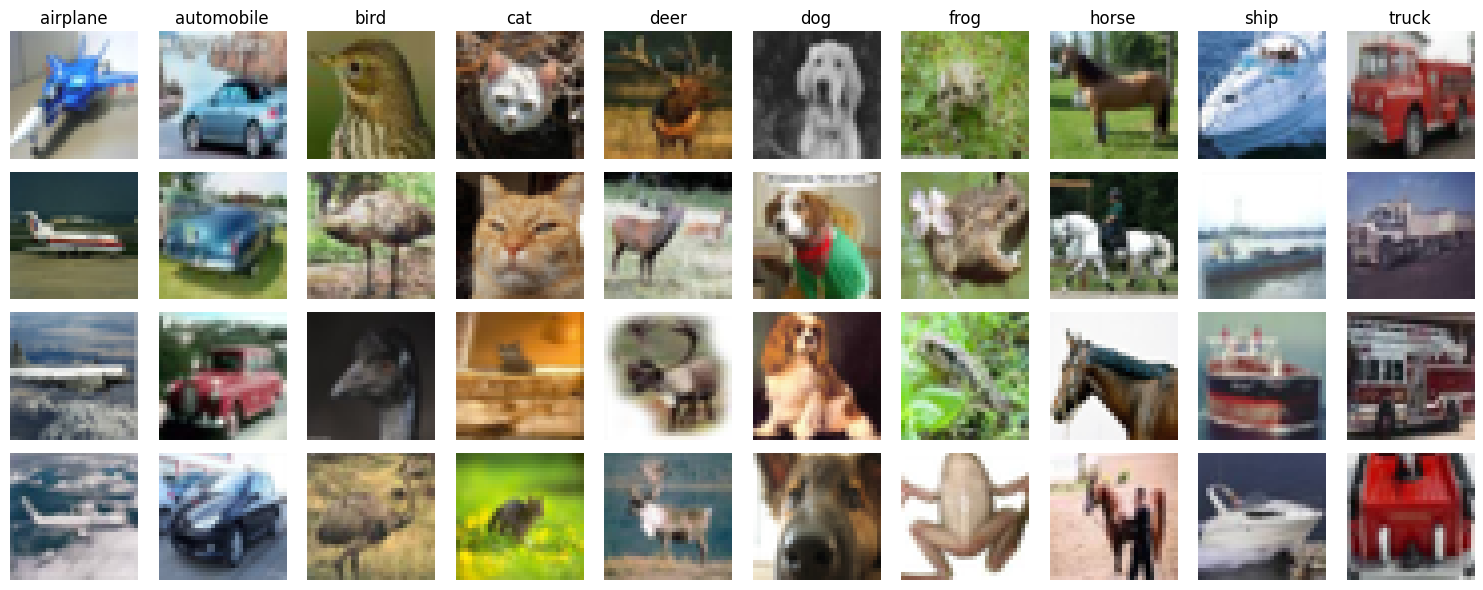

In [5]:
def visualize_cifar_samples(X: np.ndarray, y: np.ndarray, classes: List[str], samples_per_class: int = 4):
    num_classes = len(classes)
    fig, axes = plt.subplots(samples_per_class, num_classes, figsize=(15, 6))
    
    for y_idx, cls_name in enumerate(classes):
        idxs = np.flatnonzero(y == y_idx)
        idxs = np.random.choice(idxs, samples_per_class, replace=False)
        
        for i, idx in enumerate(idxs):
            ax = axes[i, y_idx]
            ax.imshow(X[idx])
            ax.axis('off')
            if i == 0:
                ax.set_title(cls_name)
                
    plt.tight_layout()
    plt.show()

visualize_cifar_samples(X_train_cifar, y_train_cifar, cifar_classes)

X_train_flat = X_train_cifar.reshape(X_train_cifar.shape[0], -1)
X_test_flat = X_test_cifar.reshape(X_test_cifar.shape[0], -1)

X_train_flat = np.hstack([X_train_flat, np.ones((X_train_flat.shape[0], 1))])
X_test_flat = np.hstack([X_test_flat, np.ones((X_test_flat.shape[0], 1))])

## Задание 3
Создайте класс линейного классификатора с возможностью задавать число входных нейронов и число выходных нейронов. Подготовьте изображения в одномерном представлении для подачи на вход такого классификатора и используйте правильные параметры для нейросети. Посчитайте прогон такой модели при случайной инициализации весовых коэффициентов.

In [6]:
class LinearClassifier:
    def __init__(self, input_dim: int, num_classes: int):
        # [input_dim, num_classes] (например, 3073 x 10)
        self.W = np.random.randn(input_dim, num_classes) * 0.001
        
    def predict(self, X: np.ndarray) -> np.ndarray:
        # X:[N, D] x W: [D, C] -> scores: [N, C]
        scores = X.dot(self.W)
        return scores

lc = LinearClassifier(input_dim=3073, num_classes=10)
scores_sample = lc.predict(X_train_flat[:10])
scores_sample

array([[ 3.46269841e-02, -4.55570075e-02, -2.39464736e-02,
        -2.60304084e-03, -2.55916354e-02,  3.60351964e-02,
         1.88876883e-02,  2.89272284e-02, -6.20694815e-03,
        -5.08331350e-03],
       [ 5.68019000e-03, -3.52267423e-02, -1.67826586e-02,
         1.98199078e-03, -4.93971009e-03,  1.09131773e-02,
        -1.96022132e-02,  1.59156936e-02,  1.53129261e-02,
        -4.88209639e-02],
       [ 9.94499233e-03, -3.53459294e-02,  4.06745002e-04,
        -2.48236031e-02, -6.14249623e-02,  2.03583461e-03,
        -5.29205935e-03,  2.47196362e-02,  7.90457147e-03,
        -1.25679145e-06],
       [ 1.66998663e-02, -3.07839348e-02, -2.55326725e-02,
        -4.14475712e-03, -9.90470913e-03,  2.23619007e-02,
         1.27729363e-03,  2.07975691e-02,  1.47538541e-03,
        -9.70939821e-03],
       [ 2.35154550e-02, -5.23780608e-02, -1.68689071e-02,
         3.19171205e-03, -5.90012004e-03,  2.04830890e-02,
         5.72036177e-03,  8.10570574e-03,  1.39778394e-02,
        -2.

## Задание 4
Доработайте код задания 3, добавив активацию с помощью функции softmax

In [7]:
def get_probs(self, scores: np.ndarray) -> np.ndarray:
    """Активация Softmax: превращает "очки" в вероятности от 0 до 1"""
    exp_scores = np.exp(scores - np.max(scores, axis=1, keepdims=True))
    probs = exp_scores / np.sum(exp_scores, axis=1, keepdims=True)
    return probs

LinearClassifier.get_probs = get_probs

scores_10 = lc.predict(X_train_flat[:10])

probs_sample = lc.get_probs(scores_10)
print("Пример вероятностей для первого образца:")
print(np.round(probs_sample[0], 3))

Пример вероятностей для первого образца:
[0.103 0.095 0.098 0.1   0.097 0.104 0.102 0.103 0.099 0.099]


## Задание 5
Выполните реализацию подсчета svm-hinge-loss (https://stackoverflow.com/questions/34325759/whats-the-relationship-between-an-svm-and-hinge-loss), добавив соответствующий метод в класс классификатора.

In [8]:
def svm_loss(self, scores: np.ndarray, y: np.ndarray, reg_strength: float = 0.1) -> float:
    """Подсчет Hinge Loss для метода опорных векторов (SVM)"""
    num_samples = scores.shape[0]
    
    correct_class_scores = scores[np.arange(num_samples), y].reshape(-1, 1)
    
    margins = np.maximum(0, scores - correct_class_scores + 1.0)
    
    margins[np.arange(num_samples), y] = 0 
    
    loss = np.sum(margins) / num_samples
    loss += 0.5 * reg_strength * np.sum(self.W * self.W)
    return loss

LinearClassifier.svm_loss = svm_loss

loss_svm = lc.svm_loss(scores_10, y_train_cifar[:10], reg_strength=0.1)
print(f"Рассчитанные потери (SVM): {loss_svm:.2f}")

Рассчитанные потери (SVM): 9.06


## Задание 6
Реализуйте функцию softmax-loss и cross-entropy-loss

In [9]:
def softmax_loss(self, scores: np.ndarray, y: np.ndarray, reg_strength: float = 0.1) -> float:
    """Подсчет Cross-Entropy Loss после Softmax"""
    num_samples = scores.shape[0]
    probs = self.get_probs(scores)
    
    correct_probs = probs[np.arange(num_samples), y]
    
    loss = -np.sum(np.log(correct_probs + 1e-10)) / num_samples
    loss += 0.5 * reg_strength * np.sum(self.W * self.W)
    return loss

LinearClassifier.softmax_loss = softmax_loss

loss_soft = lc.softmax_loss(scores_10, y_train_cifar[:10], reg_strength=0.1)
print(f"Softmax loss: {loss_soft:.2f}")

Softmax loss: 2.31


### Задание 7*
Реализация оценки градиента
Примечание: Можно ее оставить сделанной

In [10]:
def compute_gradient(self, X: np.ndarray, y_true: np.ndarray, scores: np.ndarray, 
                     loss_type: str='svm', reg_strength: float=0.1) -> np.ndarray:
    """Вычисление градиентов весов для обновления модели"""
    num_samples = X.shape[0]
    dscores = np.zeros_like(scores)
    
    if loss_type == 'svm':
        margins = (scores - scores[np.arange(num_samples), y_true][:, None] + 1)
        dscores = (margins > 0).astype(float)
        dscores[np.arange(num_samples), y_true] -= np.sum(dscores, axis=1)
        dscores /= num_samples
    else: # softmax
        probs = self.get_probs(scores)
        dscores = probs.copy()
        dscores[np.arange(num_samples), y_true] -= 1
        dscores /= num_samples
        
    dW = X.T.dot(dscores)
    dW += reg_strength * self.W 
    return dW

LinearClassifier.compute_gradient = compute_gradient

gradient = lc.compute_gradient(X_train_flat[:10], y_train_cifar[:10], scores_10, loss_type='softmax')
print("Градиент весов (первые 3 строки, 3 столбца):")
print(gradient[:3, :3])

Градиент весов (первые 3 строки, 3 столбца):
[[ 0.05069349 -0.08053473 -0.01471799]
 [ 0.05398291 -0.05944233 -0.02860651]
 [ 0.05087469 -0.06904859  0.01658449]]


## Задание 8
Добавьте функцию обучения классификатора с выводом потерь и построением графика после обучения

Epoch 1/10, Loss: 6.3395
Epoch 2/10, Loss: 5.3581
Epoch 3/10, Loss: 5.1080
Epoch 4/10, Loss: 4.9803
Epoch 5/10, Loss: 4.8882
Epoch 6/10, Loss: 4.8214
Epoch 7/10, Loss: 4.7792
Epoch 8/10, Loss: 4.7284
Epoch 9/10, Loss: 4.7011
Epoch 10/10, Loss: 4.6744


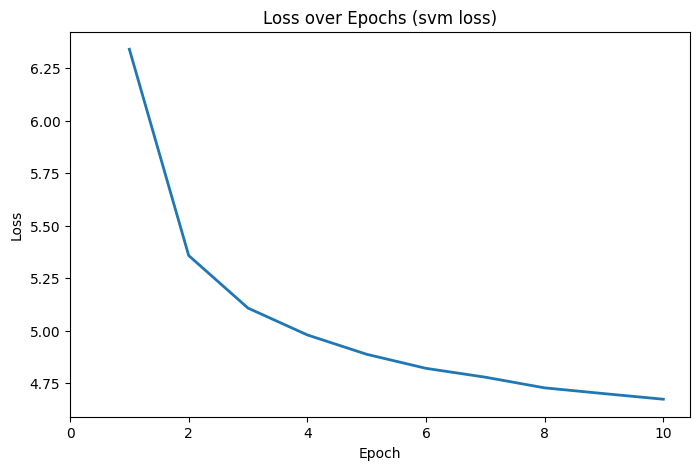

In [11]:
def train(self, X: np.ndarray, y: np.ndarray, learning_rate: float=1e-3, 
          reg: float=1e-5, epochs: int=10, batch_size: int=200, loss_type: str='svm'):
    """Главный цикл обучения (Mini-Batch Gradient Descent)"""
    num_train = X.shape[0]
    loss_history =[]
    
    for epoch in range(epochs):
        indices = np.random.permutation(num_train)
        X_shuffled = X[indices]
        y_shuffled = y[indices]
        
        epoch_loss = 0
        num_batches = num_train // batch_size
        
        for i in range(0, num_train, batch_size):
            X_batch = X_shuffled[i : i + batch_size]
            y_batch = y_shuffled[i : i + batch_size]
            
            scores = self.predict(X_batch)
            
            if loss_type == 'softmax':
                loss = self.softmax_loss(scores, y_batch, reg)
            else:
                loss = self.svm_loss(scores, y_batch, reg)
            epoch_loss += loss
            
            dW = self.compute_gradient(X_batch, y_batch, scores, loss_type, reg)
            self.W -= learning_rate * dW
            
        avg_loss = epoch_loss / num_batches
        loss_history.append(avg_loss)
        print(f"Epoch {epoch+1}/{epochs}, Loss: {avg_loss:.4f}")
        
    return loss_history

LinearClassifier.train = train

lc_svm = LinearClassifier(input_dim=X_train_flat.shape[1], num_classes=10)
loss_hist_svm = lc_svm.train(X_train_flat, y_train_cifar, learning_rate=1e-3, reg=0.01, epochs=10, batch_size=256, loss_type='svm')

plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), loss_hist_svm, linewidth=2)
plt.title("Loss over Epochs (svm loss)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.xticks(range(0, 11, 2))
plt.show()

## Задание 9
Поэксперементируйте с параметрами обучения

Epoch 1/20, Loss: 2.2777
Epoch 2/20, Loss: 2.2189
Epoch 3/20, Loss: 2.1757
Epoch 4/20, Loss: 2.1424
Epoch 5/20, Loss: 2.1159
Epoch 6/20, Loss: 2.0946
Epoch 7/20, Loss: 2.0767
Epoch 8/20, Loss: 2.0613
Epoch 9/20, Loss: 2.0481
Epoch 10/20, Loss: 2.0368
Epoch 11/20, Loss: 2.0265
Epoch 12/20, Loss: 2.0180
Epoch 13/20, Loss: 2.0093
Epoch 14/20, Loss: 2.0019
Epoch 15/20, Loss: 1.9956
Epoch 16/20, Loss: 1.9898
Epoch 17/20, Loss: 1.9838
Epoch 18/20, Loss: 1.9788
Epoch 19/20, Loss: 1.9740
Epoch 20/20, Loss: 1.9694


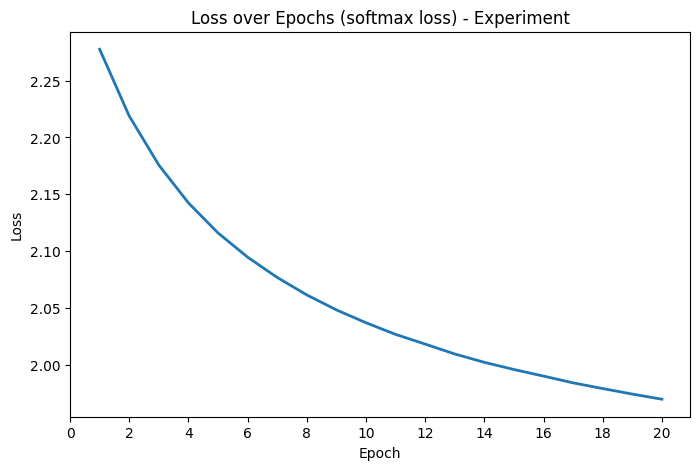

In [12]:
lc_soft = LinearClassifier(input_dim=X_train_flat.shape[1], num_classes=10)

loss_hist_soft = lc_soft.train(
    X=X_train_flat, 
    y=y_train_cifar, 
    learning_rate=5e-4,
    reg=0.05,
    epochs=20,
    batch_size=256, 
    loss_type='softmax'
)

# Построение графика эксперимента
plt.figure(figsize=(8, 5))
plt.plot(range(1, 21), loss_hist_soft, linewidth=2)
plt.title("Loss over Epochs (softmax loss) - Experiment")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.xticks(range(0, 21, 2))
plt.show()

## Задание 10
Выполните оценку качества модели на тестовых данных с помощью classification_report

In [13]:
test_scores = lc.predict(X_test_flat)
y_pred_custom = np.argmax(test_scores, axis=1)
print(classification_report(y_test_cifar, y_pred_custom, target_names=cifar_classes))

              precision    recall  f1-score   support

    airplane       0.02      0.01      0.02      1000
  automobile       0.00      0.00      0.00      1000
        bird       0.00      0.00      0.00      1000
         cat       0.19      0.01      0.02      1000
        deer       0.00      0.00      0.00      1000
         dog       0.11      0.19      0.14      1000
        frog       0.10      0.00      0.01      1000
       horse       0.11      0.71      0.19      1000
        ship       0.19      0.14      0.16      1000
       truck       0.29      0.00      0.00      1000

    accuracy                           0.11     10000
   macro avg       0.10      0.11      0.05     10000
weighted avg       0.10      0.11      0.05     10000



c:\Users\Rog G16\.conda\envs\FU\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Rog G16\.conda\envs\FU\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Rog G16\.conda\envs\FU\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


## Задание 11
Выполните визуализацию изображений, прогнозных значений и реальных значений

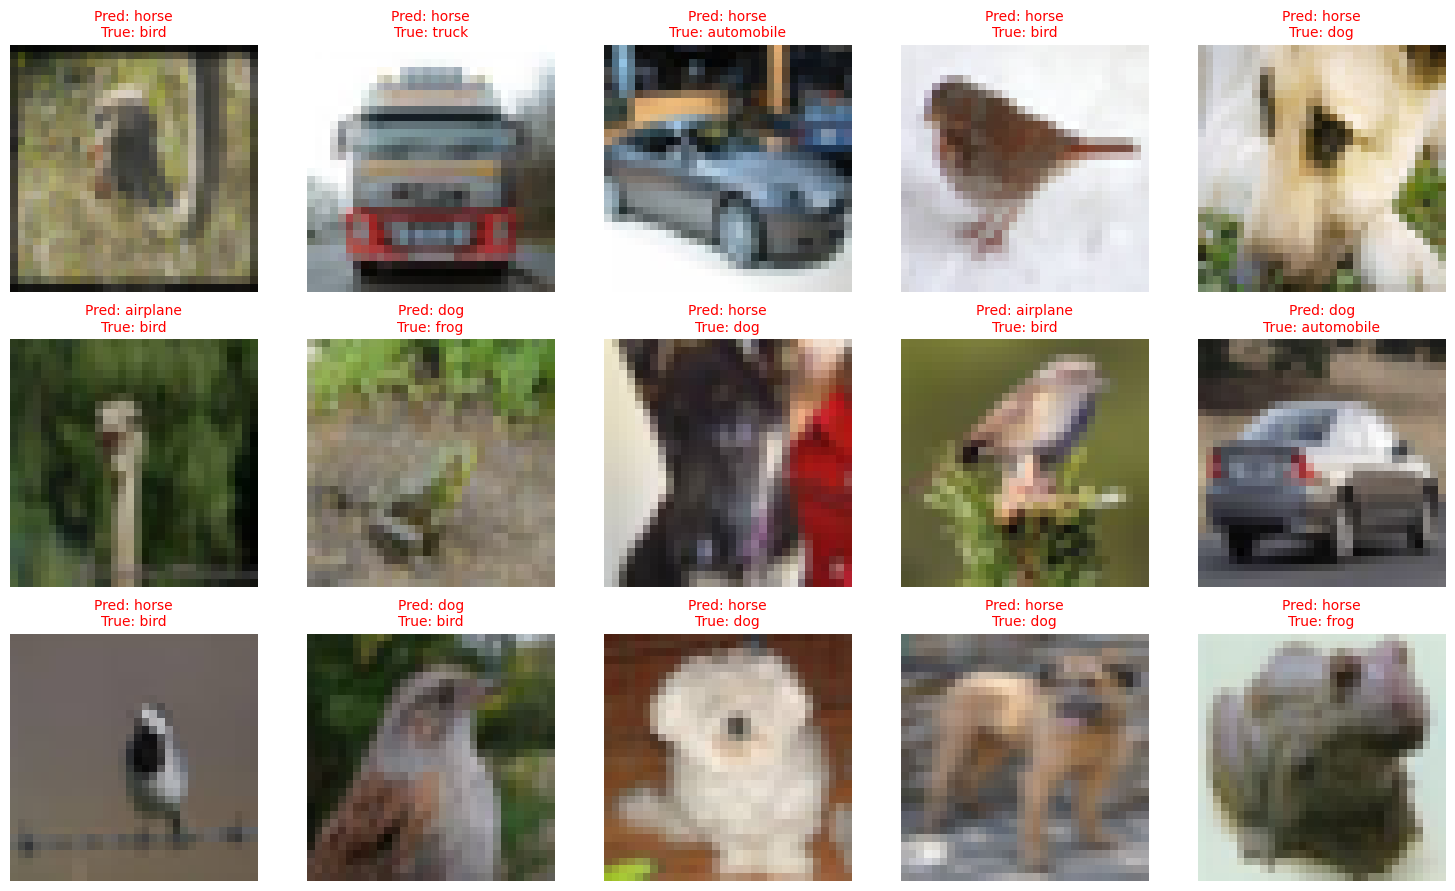

In [14]:
def visualize_predictions(X_img: np.ndarray, y_true: np.ndarray, y_pred: np.ndarray, classes: List[str]):
    fig, axes = plt.subplots(3, 5, figsize=(15, 9))
    idxs = np.random.choice(len(X_img), 15, replace=False)
    
    for i, idx in enumerate(idxs):
        ax = axes[i // 5, i % 5]
        ax.imshow(X_img[idx])
        ax.axis('off')
        
        pred_label = classes[y_pred[idx]]
        true_label = classes[y_true[idx]]
        color = 'green' if pred_label == true_label else 'red'
        
        ax.set_title(f"Pred: {pred_label}\nTrue: {true_label}", color=color, fontsize=10)
        
    plt.tight_layout()
    plt.show()

visualize_predictions(X_test_cifar, y_test_cifar, y_pred_custom, cifar_classes)

In [15]:
visualize_predictions(lc, X_train[:100], y_train[:100])

TypeError: visualize_predictions() missing 1 required positional argument: 'classes'

## Задание 14*
Попробуйте сравнить вашу модель со встроенным SVM, Random Forest и LogReg классификаторами

In [ ]:
idx_subset = np.random.choice(len(X_train_flat), 10000, replace=False)
X_train_sub = X_train_flat[idx_subset]
y_train_sub = y_train_cifar[idx_subset]

sklearn_models = {
    'Linear SVM (SGD)': SGDClassifier(loss='hinge', max_iter=20, random_state=42),
    'Logistic Reg (SGD)': SGDClassifier(loss='log_loss', max_iter=20, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=50, max_depth=10, n_jobs=-1, random_state=42)
}

for name, model in sklearn_models.items():
    model.fit(X_train_sub, y_train_sub)
    y_pred_sk = model.predict(X_test_flat)
    acc = accuracy_score(y_test_cifar, y_pred_sk)
    print(f"{name}: Accuracy = {acc:.4f}")

c:\Users\Rog G16\.conda\envs\FU\Lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:733: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


Linear SVM (SGD): Accuracy = 0.2967


c:\Users\Rog G16\.conda\envs\FU\Lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:733: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


Logistic Reg (SGD): Accuracy = 0.3049
Random Forest: Accuracy = 0.3948


In [ ]:

models = {
    'Linear SVM (SGD)': SGDClassifier(
        loss='hinge',
        penalty='l2',
        max_iter=10,
        learning_rate='optimal',
        eta0=0.001,
        random_state=42
    ),
    'Logistic Regression (SGD)': SGDClassifier(
        loss='log_loss',
        penalty='l2',
        max_iter=10,
        learning_rate='optimal',
        eta0=0.001,
        random_state=42
    ),
    'Random Forest (optimized)': RandomForestClassifier(
        n_estimators=50,
        max_depth=10,
        n_jobs=-1,
        random_state=42
    )
}

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(



Model: Linear SVM (SGD)
Training time: 28.12 sec
Accuracy: 0.2515
              precision    recall  f1-score   support

    airplane       0.40      0.53      0.45      1000
  automobile       0.61      0.19      0.29      1000
        bird       0.22      0.23      0.22      1000
         cat       0.15      0.41      0.22      1000
        deer       0.44      0.06      0.11      1000
         dog       0.17      0.60      0.27      1000
        frog       0.44      0.17      0.25      1000
       horse       0.64      0.14      0.23      1000
        ship       0.67      0.01      0.02      1000
       truck       0.52      0.17      0.26      1000

    accuracy                           0.25     10000
   macro avg       0.43      0.25      0.23     10000
weighted avg       0.43      0.25      0.23     10000



/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(



Model: Logistic Regression (SGD)
Training time: 55.07 sec
Accuracy: 0.2486
              precision    recall  f1-score   support

    airplane       0.43      0.48      0.45      1000
  automobile       0.45      0.37      0.41      1000
        bird       0.23      0.18      0.20      1000
         cat       0.13      0.72      0.22      1000
        deer       0.41      0.06      0.10      1000
         dog       0.38      0.12      0.18      1000
        frog       0.31      0.33      0.32      1000
       horse       0.77      0.08      0.14      1000
        ship       0.59      0.09      0.15      1000
       truck       0.54      0.07      0.12      1000

    accuracy                           0.25     10000
   macro avg       0.42      0.25      0.23     10000
weighted avg       0.42      0.25      0.23     10000


Model: Random Forest (optimized)
Training time: 55.70 sec
Accuracy: 0.4283
              precision    recall  f1-score   support

    airplane       0.52      0.53 

## Задание 15
Создайте нелинейную модель ИНС с одним или более скрытым слоем, обучите ее и проверьте точность. По желанию можно добавить BatchNorm и DropOut слои.

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
You are using a CUDA device ('NVIDIA GeForce RTX 5070 Ti Laptop GPU') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
c:\Users\Rog G16\.conda\envs\FU\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarni

┏━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name      ┃ Type               ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ train_acc │ MulticlassAccuracy │      0 │ train │     0 │
│ 1 │ val_acc   │ MulticlassAccuracy │      0 │ train │     0 │
│ 2 │ model     │ Sequential         │  1.7 M │ train │     0 │
└───┴───────────┴────────────────────┴────────┴───────┴───────┘

Trainable params: 1.7 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 1.7 M                                                                                                
Total estimated model params size (MB): 6                                                                          
Modules in train mode: 13                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

c:\Users\Rog G16\.conda\envs\FU\Lib\site-packages\pytorch_lightning\utilities\_pytree.py:21: `isinstance(treespec, 
LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.

c:\Users\Rog G16\.conda\envs\FU\Lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:429: 
Consider setting `persistent_workers=True` in 'val_dataloader' to speed up the dataloader worker initialization.

c:\Users\Rog G16\.conda\envs\FU\Lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:429: 
Consider setting `persistent_workers=True` in 'train_dataloader' to speed up the dataloader worker initialization.

`Trainer.fit` stopped: `max_epochs=15` reached.


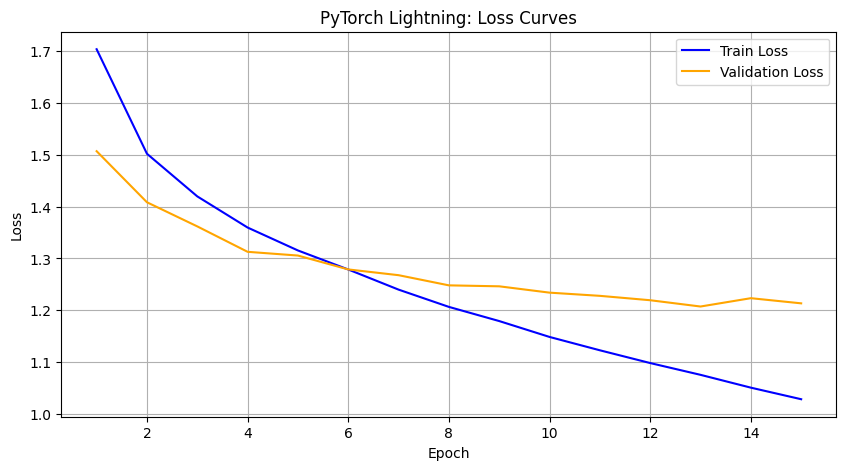

In [ ]:
class CIFAR10DataModule(pl.LightningDataModule):
    """Обертка данных для PyTorch Lightning"""
    def __init__(self, batch_size: int = 256):
        super().__init__()
        self.batch_size = batch_size
        
        self.transform = transforms.Compose([
            transforms.ToTensor(), 
            transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
        ])

    def setup(self, stage=None):
        self.cifar_train = datasets.CIFAR10(root='./data', train=True, transform=self.transform)
        self.cifar_val = datasets.CIFAR10(root='./data', train=False, transform=self.transform)

    def train_dataloader(self):
        return DataLoader(self.cifar_train, batch_size=self.batch_size, shuffle=True, num_workers=2)

    def val_dataloader(self):
        return DataLoader(self.cifar_val, batch_size=self.batch_size, shuffle=False, num_workers=2)

class MLPClassifier(pl.LightningModule):
    def __init__(self, learning_rate: float = 1e-3):
        super().__init__()
        self.save_hyperparameters() 
        
        self.train_acc = Accuracy(task="multiclass", num_classes=10)
        self.val_acc = Accuracy(task="multiclass", num_classes=10)
        
        self.epoch_train_losses =[]
        self.epoch_val_losses = []
        self.epoch_train_acc =[]
        self.epoch_val_acc =[]

        self.model = nn.Sequential(
            nn.Flatten(),
            nn.Linear(3072, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.3),
            
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),
            
            nn.Linear(256, 10) 
        )

    def forward(self, x):
        return self.model(x)

    def training_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        loss = F.cross_entropy(logits, y)
        acc = self.train_acc(logits, y)
        
        # Логируем
        self.log('train_loss', loss, on_step=False, on_epoch=True, prog_bar=True)
        self.log('train_acc', acc, on_step=False, on_epoch=True)
        return loss

    def validation_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        loss = F.cross_entropy(logits, y)
        acc = self.val_acc(logits, y)
        
        self.log('val_loss', loss, on_epoch=True, prog_bar=True)
        self.log('val_acc', acc, on_epoch=True)
        
    def on_train_epoch_end(self):
        self.epoch_train_acc.append(self.trainer.callback_metrics.get('train_acc', 0).item())
        self.epoch_train_losses.append(self.trainer.callback_metrics.get('train_loss', 0).item())

    def on_validation_epoch_end(self):
        self.epoch_val_acc.append(self.trainer.callback_metrics.get('val_loss', 0).item()) # сохраняем как в словаре
        self.epoch_val_losses.append(self.trainer.callback_metrics.get('val_loss', 0).item())

    def configure_optimizers(self):
        # Аналог from tensorflow.keras.optimizers import Adam
        return torch.optim.Adam(self.parameters(), lr=self.hparams.learning_rate)


dm = CIFAR10DataModule(batch_size=256)
model_dl = MLPClassifier(learning_rate=0.001)

trainer = pl.Trainer(
    max_epochs=15,
    accelerator='auto',
    devices=1,
    enable_progress_bar=True,
    logger=False
)

trainer.fit(model_dl, datamodule=dm)

plt.figure(figsize=(10, 5))
epochs_range = range(1, trainer.max_epochs + 1)

val_losses = model_dl.epoch_val_losses[-trainer.max_epochs:]
train_losses = model_dl.epoch_train_losses

plt.plot(epochs_range, train_losses, label='Train Loss', color='blue')
plt.plot(epochs_range, val_losses, label='Validation Loss', color='orange')
plt.title("PyTorch Lightning: Loss Curves")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
model_dl.eval()
all_preds = []
all_targets =[]

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model_dl.to(device)

with torch.no_grad():
    for x, y in dm.val_dataloader():
        x, y = x.to(device), y.to(device)
        
        logits = model_dl(x)
        
        preds = torch.argmax(logits, dim=1)
        
        all_preds.extend(preds.cpu().numpy())
        all_targets.extend(y.cpu().numpy())

y_pred_dl = np.array(all_preds)
y_true_dl = np.array(all_targets)

print(f"Accuracy: {accuracy_score(y_true_dl, y_pred_dl):.4f}")
print(classification_report(y_true_dl, y_pred_dl, target_names=cifar_classes))

Accuracy: 0.5707
--------------------------------------------------
              precision    recall  f1-score   support

    airplane       0.64      0.59      0.62      1000
  automobile       0.65      0.70      0.68      1000
        bird       0.48      0.46      0.47      1000
         cat       0.43      0.28      0.34      1000
        deer       0.50      0.48      0.49      1000
         dog       0.47      0.52      0.49      1000
        frog       0.58      0.67      0.62      1000
       horse       0.61      0.66      0.64      1000
        ship       0.64      0.72      0.68      1000
       truck       0.64      0.62      0.63      1000

    accuracy                           0.57     10000
   macro avg       0.57      0.57      0.57     10000
weighted avg       0.57      0.57      0.57     10000

